# Night-time Walking Network Analysis: Morningside Park

## Research statement

This notebook examines how a real pedestrian route through Morningside Park differs from the route that is **shortest by network distance**. The analysis begins with 9 lamp locations marked along the route actually walked on a commute to Columbia University, then compares Euclidean distance, network distance, and the observed walked route.

Euclidean distance provides a simple spatial baseline: it measures proximity as if the park were open and unobstructed. Network distance instead follows the mapped pedestrian paths, accounting for the park's stairs, switchbacks, entrances, and constrained circulation. The actual walked route adds a third perspective: it records what a person actually chose to do rather than what a distance-only model predicts.

The central question is therefore not simply **“What is the shortest route?”** but **“Why might a person choose a different route even when a shorter network path exists?”** This notebook can identify and measure that difference, but it does not yet measure the reasons for it. Lighting, visibility, familiarity, perceived safety, comfort, and other experiential factors remain hypotheses to be tested in future work.

The 9 lamp locations are real points marked along the commute route and exported from Google My Maps. Two fixed endpoints are also used for the full-commute comparison: the Columbia 116th St/Broadway gate and the Cathedral Pkwy–110th St subway station.

In result, this experiment leads into more intersting and larger field of research by asking **how human psychology impact on the path finding - and could this dataset be appliable for the future urban development.**

## Method overview

![Method workflow: log lamp positions, build walking network, snap to network, measure two ways, detour index, map and interpret]


In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
import networkx as nx
import osmnx as ox
import requests

ox.settings.log_console = False

In [2]:
# --- Visual system: editorial cartography / architectural plate ---
PAPER = "#FCF9ED"
BLUE = "#1E3C9F"
BLUE_LIGHT = "#6A8DFF"
BLUE_PALE = "#D1D3F0"
DARK = "#0E2368"
LABEL = "#4D5D91"
AMBER = "#FF6B35"
AMBER_LIGHT = "#F7C59F"
WHITE = "#FFFFFF"

plt.rcParams.update(
    {
        "figure.facecolor": PAPER,
        "axes.facecolor": PAPER,
        "savefig.facecolor": PAPER,
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.titlesize": 11,
        "axes.titleweight": "normal",
        "axes.labelsize": 8.5,
        "axes.labelcolor": DARK,
        "xtick.color": DARK,
        "ytick.color": DARK,
        "text.color": DARK,
        "legend.fontsize": 8,
    }
)


def style_ax(ax, frame=True, grid=False):
    ax.set_facecolor(PAPER)
    ax.tick_params(length=0, labelsize=8, pad=4)
    if grid:
        ax.grid(axis="y", color=BLUE_PALE, linewidth=0.7, alpha=0.8)
        ax.set_axisbelow(True)
    else:
        ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(frame)
        spine.set_color(DARK)
        spine.set_linewidth(0.8)


def style_map(ax, title=None, subtitle=None):
    ax.set_facecolor(PAPER)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(DARK)
        spine.set_linewidth(0.8)
    if title:
        ax.text(
            0.015,
            1.035,
            title.upper(),
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10,
            color=DARK,
            fontweight="bold",
        )
    if subtitle:
        ax.text(
            0.015,
            1.012,
            subtitle,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=7.5,
            color=BLUE,
        )


def add_north_arrow(ax, x=0.94, y=0.90, size=0.055):
    ax.annotate(
        "N",
        xy=(x, y + size),
        xytext=(x, y),
        xycoords="axes fraction",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color=DARK,
        arrowprops=dict(arrowstyle="-|>", color=DARK, lw=1.0),
    )


def add_scale_bar(ax, length_m=200, x=0.06, y=0.055):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    bar_x = x0 + (x1 - x0) * x
    bar_y = y0 + (y1 - y0) * y
    ax.plot(
        [bar_x, bar_x + length_m],
        [bar_y, bar_y],
        color=DARK,
        lw=2.0,
        solid_capstyle="butt",
        zorder=20,
    )
    tick = (y1 - y0) * 0.006
    ax.plot([bar_x, bar_x], [bar_y - tick, bar_y + tick], color=DARK, lw=0.8, zorder=20)
    ax.plot(
        [bar_x + length_m, bar_x + length_m],
        [bar_y - tick, bar_y + tick],
        color=DARK,
        lw=0.8,
        zorder=20,
    )
    ax.text(
        bar_x + length_m / 2,
        bar_y + (y1 - y0) * 0.018,
        f"{length_m:g} m",
        ha="center",
        va="bottom",
        fontsize=7,
        color=DARK,
    )

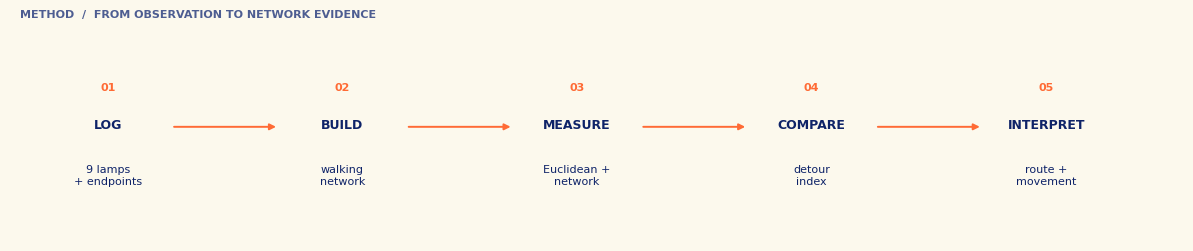

In [3]:
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 2.5)
ax.axis("off")
steps = [
    (1.0, "01", "LOG", "9 lamps\n+ endpoints"),
    (3.4, "02", "BUILD", "walking\nnetwork"),
    (5.8, "03", "MEASURE", "Euclidean +\nnetwork"),
    (8.2, "04", "COMPARE", "detour\nindex"),
    (10.6, "05", "INTERPRET", "route +\nmovement"),
]
for j, (x, num, title, body) in enumerate(steps):
    ax.text(
        x,
        1.72,
        num,
        ha="center",
        va="center",
        fontsize=8,
        color=AMBER,
        fontweight="bold",
    )
    ax.text(
        x,
        1.30,
        title,
        ha="center",
        va="center",
        fontsize=9,
        color=DARK,
        fontweight="bold",
    )
    ax.text(
        x,
        0.73,
        body,
        ha="center",
        va="center",
        fontsize=8,
        color=DARK,
        linespacing=1.25,
    )
    if j < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x + 1.75, 1.28),
            xytext=(x + 0.65, 1.28),
            arrowprops=dict(arrowstyle="-|>", color=AMBER, lw=1.4),
        )
# ax.plot([0.15, 11.65], [0.15, 0.15], color=LABEL, lw=0.8)
fig.text(
    0.02,
    0.98,
    "METHOD  /  FROM OBSERVATION TO NETWORK EVIDENCE",
    fontsize=8,
    color=LABEL,
    fontweight="bold",
    va="top",
)
plt.tight_layout()
plt.show()

## 1. Study area

Morningside Park sits between Morningside Avenue (west), Morningside Drive
(east), West 110th Street (south), and West 123rd Street (north). Use a
bounding box that includes the park itself plus a buffer of surrounding
streets, since a night walk usually starts and ends *outside* the park.

Double-check / adjust this bounding box against a real basemap before you
run this for real — it's approximate.


In [4]:
# approximate bounding box: (west, south, east, north)
# west widened to -73.9705 for the Broadway corridor (Section 3c origin);
# south widened to 40.7995 to include the B/C Cathedral Pkwy destination
# at 40.8006, which sits just south of the park itself.
bbox = (-73.9705, 40.7995, -73.9525, 40.8140)

west, south, east, north = bbox

## 2. Build the walking network graph

First, pull a pedestrian ("walk") network from OpenStreetMap covering the park
paths and the surrounding street grid in one connected graph. This is the
network will be measured distance *along*.

The download goes through OSM's Overpass API, which can time out on slow
connections, campus VPNs, or when the public server is under load. The cell
below raises the timeout, retries automatically, and falls back across a
few different Overpass mirrors (set via `ox.settings.overpass_url`, the
*base* URL -- osmnx appends `/interpreter` itself). It also caches the
result locally (`cache/` folder) so re-running the notebook later doesn't
re-download.


Trying https://overpass-api.de/api (attempt 1)...
Success.


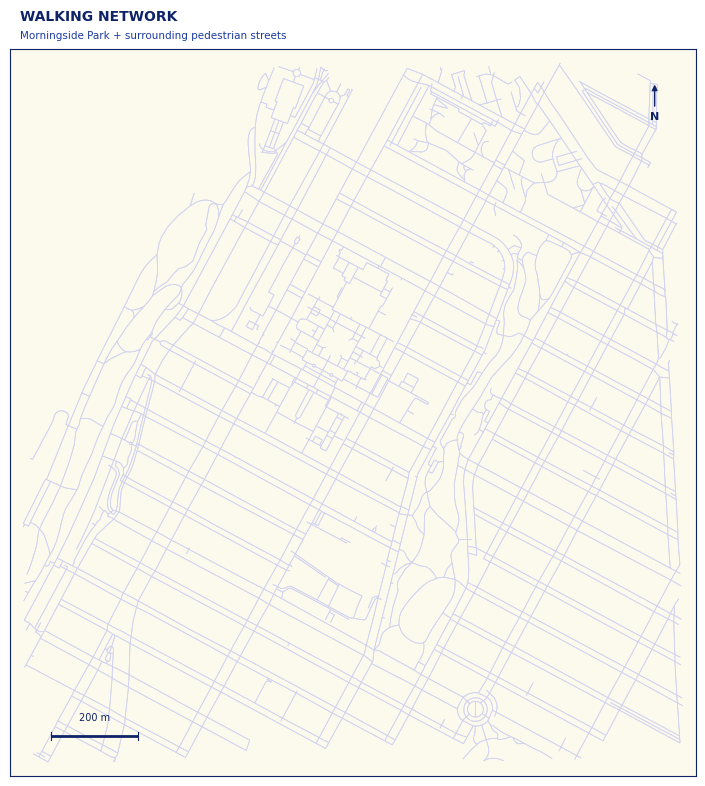

In [5]:
import os
import time

ox.settings.timeout = 300  # seconds per request (default is much lower)
ox.settings.use_cache = True
ox.settings.cache_folder = "cache"
os.makedirs("cache", exist_ok=True)

overpass_mirrors = [
    "https://overpass-api.de/api",
    "https://overpass.kumi.systems/api",
    "https://api.openstreetmap.fr/oapi",
]

G = None
last_error = None
for mirror in overpass_mirrors:
    ox.settings.overpass_url = mirror
    for attempt in range(2):
        try:
            print(f"Trying {mirror} (attempt {attempt + 1})...")
            G = ox.graph_from_bbox(bbox=bbox, network_type="walk", simplify=False)
            print("Success.")
            break
        except Exception as e:
            last_error = e
            print(f"  failed: {e}")
            time.sleep(3)
    if G is not None:
        break

if G is None:
    raise RuntimeError(
        "Could not download the network from any Overpass mirror. "
        f"Last error: {last_error}\n"
        "If you're on a campus VPN or restrictive network, try disconnecting "
        "the VPN, switching networks (e.g. mobile hotspot), or running this "
        "cell again later when the public Overpass server is less busy."
    )

# project to a metric CRS so edge lengths / distances are in meters
G_proj = ox.project_graph(G)

nodes_gdf, edges_gdf = ox.graph_to_gdfs(G_proj)

fig, ax = ox.plot_graph(
    G_proj,
    node_size=0,
    edge_color=BLUE_PALE,
    edge_linewidth=0.55,
    bgcolor=PAPER,
    show=False,
    close=False,
)
style_map(ax, "Walking network", "Morningside Park + surrounding pedestrian streets")
add_north_arrow(ax)
add_scale_bar(ax, length_m=200)
plt.tight_layout(pad=1.5)
plt.show()

## 3. Define the nodes

### 3a. Lamp nodes — real data from the walked route

These are 9 real lamp locations marked in Google My Maps along the path actually walked through Morningside Park on the commute to Columbia. They were exported to KML/CSV and cleaned into `lamp_points.csv`, with a `sequence` column preserving their order along the route.

Because the lamps occur in sequence along one real route, they allow two related comparisons: **adjacent lamp-to-lamp distances**, which show local network constraints, and the **end-to-end distance**, which captures the cumulative effect of the park's terrain, stairs, and switchbacks.

These lamp points are the primary dataset used throughout the notebook. The analysis also adds two fixed commute endpoints so the in-park route can be compared with the complete Columbia-to-Cathedral Pkwy trip.

Place `lamp_points.csv` in the `Data/` folder used by the notebook (or update the path in the loading cell).


In [6]:
lamps_gdf = pd.read_csv("./data/lamp_points.csv")
print(f"Loaded {len(lamps_gdf)} rows from lamp_points.csv")
print(lamps_gdf.head())

if len(lamps_gdf) == 0:
    raise ValueError(
        "lamp_points.csv loaded 0 rows -- the file was found (no "
        "FileNotFoundError) but is empty or header-only. Check the file "
        "itself at ./data/lamp_points.csv."
    )

lamps_gdf["type"] = "lamp"
lamps_gdf = gpd.GeoDataFrame(
    lamps_gdf,
    geometry=gpd.points_from_xy(lamps_gdf.lon, lamps_gdf.lat),
    crs="EPSG:4326",
)
lamps_gdf = lamps_gdf[["id", "type", "name", "description", "sequence", "geometry"]]

bad = lamps_gdf[
    ~lamps_gdf.geometry.y.between(40.4, 41.0)
    | ~lamps_gdf.geometry.x.between(-74.3, -73.6)
]
if len(bad) > 0:
    raise ValueError(
        "These lamp rows have coordinates outside the NYC area -- check for a "
        "lat/lon swap in lamp_points.csv (geometry uses x=lon, y=lat):\n"
        f"{bad[['id', 'name']].to_string()}"
    )

outside_bbox = lamps_gdf[
    ~lamps_gdf.geometry.y.between(south, north)
    | ~lamps_gdf.geometry.x.between(west, east)
]
if len(outside_bbox) > 0:
    print(
        "Warning: these lamps fall outside the Section 1 bbox and will snap "
        "to whatever graph node is nearest, which may be far away:\n",
        outside_bbox[["id", "name"]].to_string(),
    )

print(f"Final lamps_gdf: {len(lamps_gdf)} rows, columns: {list(lamps_gdf.columns)}")
lamps_gdf

Loaded 9 rows from lamp_points.csv
   id  sequence    name                                  description  \
0  L1         1  lamp 1  Lamp along commute route (Morningside Park)   
1  L2         2  lamp 2  Lamp along commute route (Morningside Park)   
2  L3         3  lamp 3  Lamp along commute route (Morningside Park)   
3  L4         4  lamp 4  Lamp along commute route (Morningside Park)   
4  L5         5  lamp 5  Lamp along commute route (Morningside Park)   

         lat        lon  
0  40.803237 -73.958495  
1  40.803210 -73.958644  
2  40.803245 -73.958744  
3  40.803366 -73.958943  
4  40.803356 -73.959256  
Final lamps_gdf: 9 rows, columns: ['id', 'type', 'name', 'description', 'sequence', 'geometry']


,id,type,name,description,sequence,geometry
0,L1,lamp,lamp 1,Lamp along commute route (Morningside Park),1,POINT (-73.9585 40.80324)
1,L2,lamp,lamp 2,Lamp along commute route (Morningside Park),2,POINT (-73.95864 40.80321)
2,L3,lamp,lamp 3,Lamp along commute route (Morningside Park),3,POINT (-73.95874 40.80325)
3,L4,lamp,lamp 4,Lamp along commute route (Morningside Park),4,POINT (-73.95894 40.80337)
4,L5,lamp,lamp 5,Lamp along commute route (Morningside Park),5,POINT (-73.95926 40.80336)
5,L6,lamp,lamp 6,Lamp along commute route (Morningside Park),6,POINT (-73.95953 40.80359)
6,L7,lamp,lamp 7,Lamp along commute route (Morningside Park),7,POINT (-73.95979 40.80367)
7,L8,lamp,lamp 8,Lamp along commute route (Morningside Park),8,POINT (-73.95997 40.8037)
8,L9,lamp,lamp 9,Lamp along commute route (Morningside Park),9,POINT (-73.9602 40.80388)


### 3b. Origin & destination — full commute endpoints

Two named endpoints for the full commute, independent of the 9 lamp
points: **Columbia University's 116th St/Broadway gate** (origin) and the
**Cathedral Pkwy–110th St subway station on the B/C train** (destination),
at the coordinates you supplied.

Coordinates are hardcoded rather than geocoded, since these are two fixed,
well-known points. Section 1's bbox has been widened to include both.


In [7]:
ORIGIN_NAME = "Columbia University (116th St & Broadway)"
ORIGIN_LAT, ORIGIN_LON = 40.80806, -73.96389

DEST_NAME = "Cathedral Pkwy–110th St subway station (B/C train)"
# Frederick Douglass Blvd & W 110th St
# station coordinates (40.800524, -73.958244).
DEST_LAT, DEST_LON = 40.800524, -73.958244

origin_dest_gdf = gpd.GeoDataFrame(
    {
        "id": ["origin", "destination"],
        "type": ["endpoint", "endpoint"],
        "name": [ORIGIN_NAME, DEST_NAME],
        "description": ["Commute start", "Commute end"],
        "sequence": [np.nan, np.nan],
    },
    geometry=gpd.points_from_xy([ORIGIN_LON, DEST_LON], [ORIGIN_LAT, DEST_LAT]),
    crs="EPSG:4326",
)
origin_dest_gdf

,id,type,name,description,sequence,geometry
0,origin,endpoint,Columbia University (116th St & Broadway),Commute start,NaN,POINT (-73.96389 40.80806)
1,destination,endpoint,Cathedral Pkwy–110th St subway station (B/C tr...,Commute end,NaN,POINT (-73.95824 40.80052)


### 3c. Combine into a single node table

In [8]:
nodes = pd.concat(
    [
        lamps_gdf[["id", "type", "name", "description", "sequence", "geometry"]],
        origin_dest_gdf[["id", "type", "name", "description", "sequence", "geometry"]],
    ],
    ignore_index=True,
)
nodes = gpd.GeoDataFrame(nodes, geometry="geometry", crs="EPSG:4326")

print(f"Combined nodes table: {len(nodes)} total rows")
print(nodes["type"].value_counts())
if (nodes["type"] == "lamp").sum() == 0:
    raise ValueError(
        "nodes has 0 rows with type=='lamp' even though lamps_gdf was "
        "non-empty earlier -- check that lamps_gdf's 'type' column really "
        "contains the literal string 'lamp' (e.g. print(lamps_gdf['type']"
        ".unique()) in the Section 3a cell)."
    )

nodes

Combined nodes table: 11 total rows
type
lamp        9
endpoint    2
Name: count, dtype: int64


,id,type,name,description,sequence,geometry
0,L1,lamp,lamp 1,Lamp along commute route (Morningside Park),1.0,POINT (-73.9585 40.80324)
1,L2,lamp,lamp 2,Lamp along commute route (Morningside Park),2.0,POINT (-73.95864 40.80321)
2,L3,lamp,lamp 3,Lamp along commute route (Morningside Park),3.0,POINT (-73.95874 40.80325)
3,L4,lamp,lamp 4,Lamp along commute route (Morningside Park),4.0,POINT (-73.95894 40.80337)
4,L5,lamp,lamp 5,Lamp along commute route (Morningside Park),5.0,POINT (-73.95926 40.80336)
5,L6,lamp,lamp 6,Lamp along commute route (Morningside Park),6.0,POINT (-73.95953 40.80359)
6,L7,lamp,lamp 7,Lamp along commute route (Morningside Park),7.0,POINT (-73.95979 40.80367)
7,L8,lamp,lamp 8,Lamp along commute route (Morningside Park),8.0,POINT (-73.95997 40.8037)
8,L9,lamp,lamp 9,Lamp along commute route (Morningside Park),9.0,POINT (-73.9602 40.80388)
9,origin,endpoint,Columbia University (116th St & Broadway),Commute start,NaN,POINT (-73.96389 40.80806)


## 4. Plot nodes on the network

About to plot: 9 lamps, 0 viewpoints, 1 origin, 1 destination


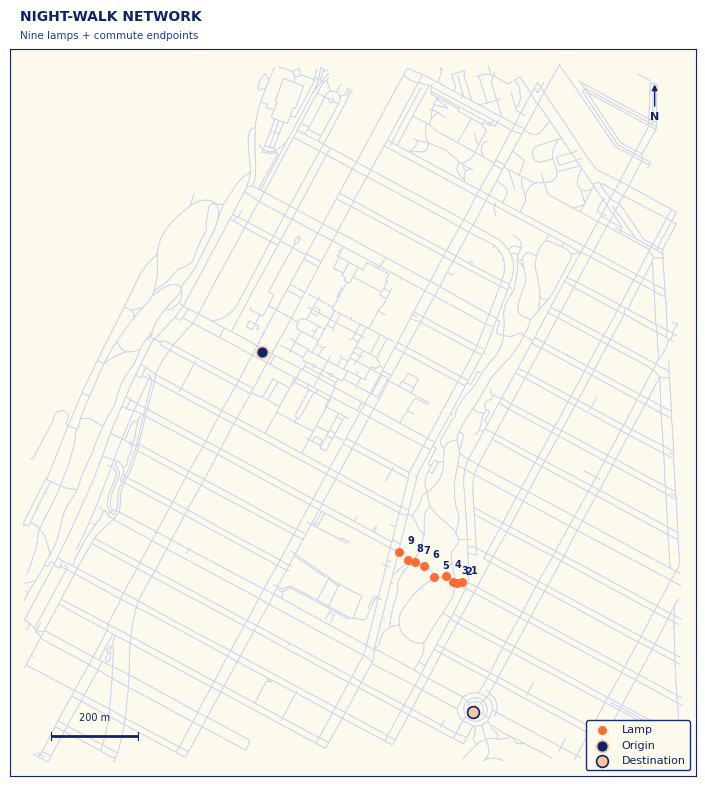

In [9]:
nodes_proj = nodes.to_crs(G_proj.graph["crs"])

lamp_pts = nodes_proj[nodes_proj["type"] == "lamp"]
view_pts = nodes_proj[nodes_proj["type"] == "viewpoint"]
origin_pt = nodes_proj[nodes_proj["id"] == "origin"]
dest_pt = nodes_proj[nodes_proj["id"] == "destination"]

print(
    f"About to plot: {len(lamp_pts)} lamps, {len(view_pts)} viewpoints, {len(origin_pt)} origin, {len(dest_pt)} destination"
)

fig, ax = ox.plot_graph(
    G_proj,
    node_size=0,
    edge_color=BLUE_PALE,
    edge_linewidth=0.55,
    bgcolor=PAPER,
    show=False,
    close=False,
)
ax.scatter(
    lamp_pts.geometry.x,
    lamp_pts.geometry.y,
    c=AMBER,
    s=30,
    # edgecolors=WHITE,
    # linewidths=0.8,
    label="Lamp",
    zorder=8,
)
for _, row in lamp_pts.sort_values("sequence").iterrows():
    ax.annotate(
        str(int(row["sequence"])),
        (row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=7,
        color=DARK,
        fontweight="bold",
        zorder=9,
    )
if len(origin_pt) > 0:
    ax.scatter(
        origin_pt.geometry.x,
        origin_pt.geometry.y,
        c=DARK,
        s=72,
        marker="o",
        edgecolors=AMBER_LIGHT,
        linewidths=1.2,
        label="Origin",
        zorder=9,
    )
if len(dest_pt) > 0:
    ax.scatter(
        dest_pt.geometry.x,
        dest_pt.geometry.y,
        facecolors=AMBER_LIGHT,
        edgecolors=DARK,
        s=72,
        marker="o",
        linewidths=1.2,
        label="Destination",
        zorder=9,
    )

all_x = nodes_proj.geometry.x
all_y = nodes_proj.geometry.y
xlim = ax.get_xlim()
ylim = ax.get_ylim()
pad_x = (all_x.max() - all_x.min()) * 0.10 or 50
pad_y = (all_y.max() - all_y.min()) * 0.10 or 50
ax.set_xlim(min(xlim[0], all_x.min() - pad_x), max(xlim[1], all_x.max() + pad_x))
ax.set_ylim(min(ylim[0], all_y.min() - pad_y), max(ylim[1], all_y.max() + pad_y))
style_map(ax, "Night-walk network", "Nine lamps + commute endpoints")
add_north_arrow(ax)
add_scale_bar(ax, length_m=200)
ax.legend(
    loc="lower right", frameon=True, facecolor=PAPER, edgecolor=DARK, framealpha=0.95
)
plt.tight_layout(pad=1.5)
plt.show()

About to plot: 9 lamps, 0 viewpoints, 1 origin, 1 destination


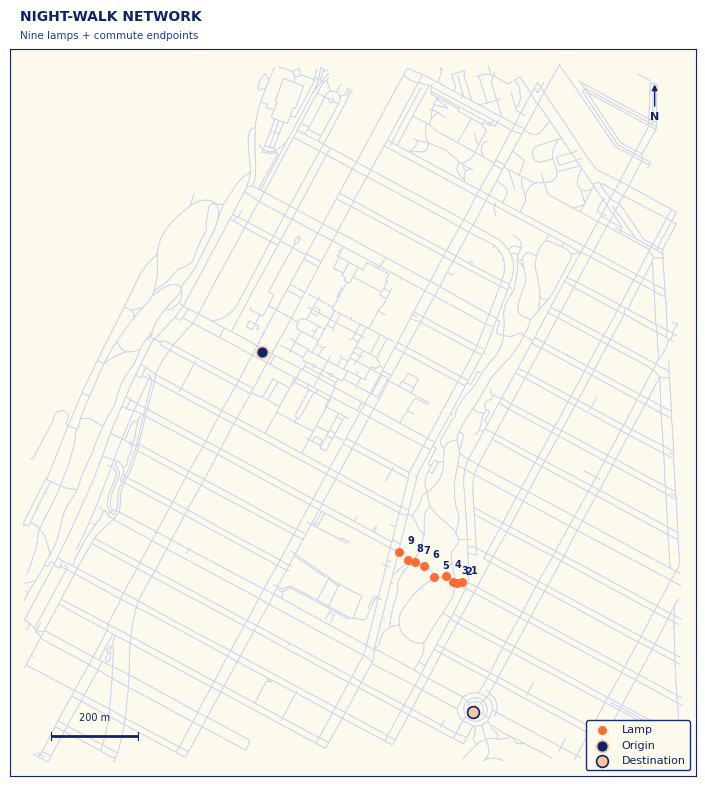

In [10]:
nodes_proj = nodes.to_crs(G_proj.graph["crs"])

lamp_pts = nodes_proj[nodes_proj["type"] == "lamp"]
view_pts = nodes_proj[nodes_proj["type"] == "viewpoint"]
origin_pt = nodes_proj[nodes_proj["id"] == "origin"]
dest_pt = nodes_proj[nodes_proj["id"] == "destination"]

print(
    f"About to plot: {len(lamp_pts)} lamps, {len(view_pts)} viewpoints, {len(origin_pt)} origin, {len(dest_pt)} destination"
)

fig, ax = ox.plot_graph(
    G_proj,
    node_size=0,
    edge_color=BLUE_PALE,
    edge_linewidth=0.55,
    bgcolor=PAPER,
    show=False,
    close=False,
)
ax.scatter(
    lamp_pts.geometry.x,
    lamp_pts.geometry.y,
    c=AMBER,
    s=30,
    # edgecolors=WHITE,
    # linewidths=0.8,
    label="Lamp",
    zorder=8,
)
for _, row in lamp_pts.sort_values("sequence").iterrows():
    ax.annotate(
        str(int(row["sequence"])),
        (row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=7,
        color=DARK,
        fontweight="bold",
        zorder=9,
    )
if len(origin_pt) > 0:
    ax.scatter(
        origin_pt.geometry.x,
        origin_pt.geometry.y,
        c=DARK,
        s=72,
        marker="o",
        edgecolors=AMBER_LIGHT,
        linewidths=1.2,
        label="Origin",
        zorder=9,
    )
if len(dest_pt) > 0:
    ax.scatter(
        dest_pt.geometry.x,
        dest_pt.geometry.y,
        facecolors=AMBER_LIGHT,
        edgecolors=DARK,
        s=72,
        marker="o",
        linewidths=1.2,
        label="Destination",
        zorder=9,
    )

all_x = nodes_proj.geometry.x
all_y = nodes_proj.geometry.y
xlim = ax.get_xlim()
ylim = ax.get_ylim()
pad_x = (all_x.max() - all_x.min()) * 0.10 or 50
pad_y = (all_y.max() - all_y.min()) * 0.10 or 50
ax.set_xlim(min(xlim[0], all_x.min() - pad_x), max(xlim[1], all_x.max() + pad_x))
ax.set_ylim(min(ylim[0], all_y.min() - pad_y), max(ylim[1], all_y.max() + pad_y))
style_map(ax, "Night-walk network", "Nine lamps + commute endpoints")
add_north_arrow(ax)
add_scale_bar(ax, length_m=200)
ax.legend(
    loc="lower right", frameon=True, facecolor=PAPER, edgecolor=DARK, framealpha=0.95
)
plt.tight_layout(pad=1.5)
plt.show()

## 5. Snap each node to the nearest network node

To measure network distance we need every point to sit on the graph. We
snap each lamp/viewpoint to its nearest graph node.


In [11]:
nodes_proj["nearest_node"] = ox.distance.nearest_nodes(
    G_proj, X=nodes_proj.geometry.x, Y=nodes_proj.geometry.y
)
nodes_proj[["id", "type", "name", "nearest_node"]]

,id,type,name,nearest_node
0,L1,lamp,lamp 1,1775693149
1,L2,lamp,lamp 2,7997766217
2,L3,lamp,lamp 3,1774036757
3,L4,lamp,lamp 4,1774037281
4,L5,lamp,lamp 5,1775693416
5,L6,lamp,lamp 6,1775693111
6,L7,lamp,lamp 7,1775693103
7,L8,lamp,lamp 8,1775693453
8,L9,lamp,lamp 9,11952891944
9,origin,endpoint,Columbia University (116th St & Broadway),8379911359


## 6. Euclidean distance matrix

Straight-line distance between every pair of nodes, computed in a projected
(metric) CRS so units are meters.


In [12]:
coords = np.array(list(zip(nodes_proj.geometry.x, nodes_proj.geometry.y)))
ids = nodes_proj["id"].values

euclid_matrix = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=2))
euclid_df = pd.DataFrame(euclid_matrix, index=ids, columns=ids)
euclid_df.round(1)

,L1,L2,L3,L4,L5,L6,L7,L8,L9,origin,destination
L1,0.0,12.9,20.9,40.4,65.5,95.4,119.0,134.6,160.9,702.7,301.9
L2,12.9,0.0,9.3,30.6,54.1,85.5,109.0,124.5,151.2,697.0,300.1
L3,20.9,9.3,0.0,21.5,44.9,76.3,99.8,115.2,142.0,688.6,305.0
L4,40.4,30.6,21.5,0.0,26.4,55.1,78.7,94.3,120.7,667.6,321.0
L5,65.5,54.1,44.9,26.4,0.0,34.4,56.6,71.5,99.0,652.3,325.8
L6,95.4,85.5,76.3,55.1,34.4,0.0,23.7,39.3,65.7,618.1,356.8
L7,119.0,109.0,99.8,78.7,56.6,23.7,0.0,15.7,42.4,598.1,372.3
L8,134.6,124.5,115.2,94.3,71.5,39.3,15.7,0.0,27.9,585.8,381.9
L9,160.9,151.2,142.0,120.7,99.0,65.7,42.4,27.9,0.0,558.5,407.8
origin,702.7,697.0,688.6,667.6,652.3,618.1,598.1,585.8,558.5,0.0,962.7


## 7. Network distance matrix

Shortest-path distance along the walking network between every pair of
nodes, using edge length (meters) as the weight.


In [13]:
network_matrix = pd.DataFrame(index=ids, columns=ids, dtype=float)

node_lookup = dict(zip(nodes_proj["id"], nodes_proj["nearest_node"]))

for a in ids:
    lengths = nx.single_source_dijkstra_path_length(
        G_proj, node_lookup[a], weight="length"
    )
    for b in ids:
        target = node_lookup[b]
        network_matrix.loc[a, b] = lengths.get(target, np.nan)

network_matrix.round(1)

,L1,L2,L3,L4,L5,L6,L7,L8,L9,origin,destination
L1,0.0,26.1,12.5,43.9,60.6,98.1,121.5,133.8,176.7,831.3,405.6
L2,26.1,0.0,13.6,45.0,61.6,99.2,122.5,134.9,177.7,832.4,401.8
L3,12.5,13.6,0.0,31.4,48.1,85.6,109.0,121.3,164.2,818.8,415.3
L4,43.9,45.0,31.4,0.0,27.8,65.3,88.7,101.1,143.9,813.2,446.8
L5,60.6,61.6,48.1,27.8,0.0,37.5,60.9,73.3,116.1,823.4,463.4
L6,98.1,99.2,85.6,65.3,37.5,0.0,23.4,35.7,78.6,785.9,500.9
L7,121.5,122.5,109.0,88.7,60.9,23.4,0.0,12.3,55.2,762.5,517.9
L8,133.8,134.9,121.3,101.1,73.3,35.7,12.3,0.0,42.8,750.2,519.6
L9,176.7,177.7,164.2,143.9,116.1,78.6,55.2,42.8,0.0,718.0,519.3
origin,831.3,832.4,818.8,813.2,823.4,785.9,762.5,750.2,718.0,0.0,1234.1


## 8. Compare Euclidean vs. network distance

Then reshape both matrices into a long "pair" table and compute a **detour
index** = network distance ÷ Euclidean distance. A detour index near 1
means the path network barely constrains movement; a high value means the
network forces a much longer route than the straight-line gap suggests.


In [14]:
pairs = []
for i, a in enumerate(ids):
    for b in ids[i + 1 :]:
        eu = euclid_df.loc[a, b]
        net = network_matrix.loc[a, b]
        pairs.append(
            {
                "node_a": a,
                "node_b": b,
                "euclidean_m": eu,
                "network_m": net,
                "detour_index": net / eu if eu > 0 else np.nan,
            }
        )

compare_df = pd.DataFrame(pairs).sort_values("detour_index", ascending=False)
compare_df.reset_index(drop=True)

,node_a,node_b,euclidean_m,network_m,detour_index
0,L1,L2,12.915948,26.055409,2.017305
1,L8,L9,27.925241,42.838110,1.534028
2,L2,L4,30.622379,44.999130,1.469485
3,L2,L3,9.257643,13.556586,1.464367
4,L3,L4,21.539209,31.442545,1.459782
5,L5,destination,325.774564,463.396187,1.422444
6,L6,destination,356.819477,500.937659,1.403897
7,L4,destination,320.977520,446.772402,1.391912
8,L7,destination,372.316385,517.873125,1.390949
9,L3,destination,305.023161,415.329857,1.361634


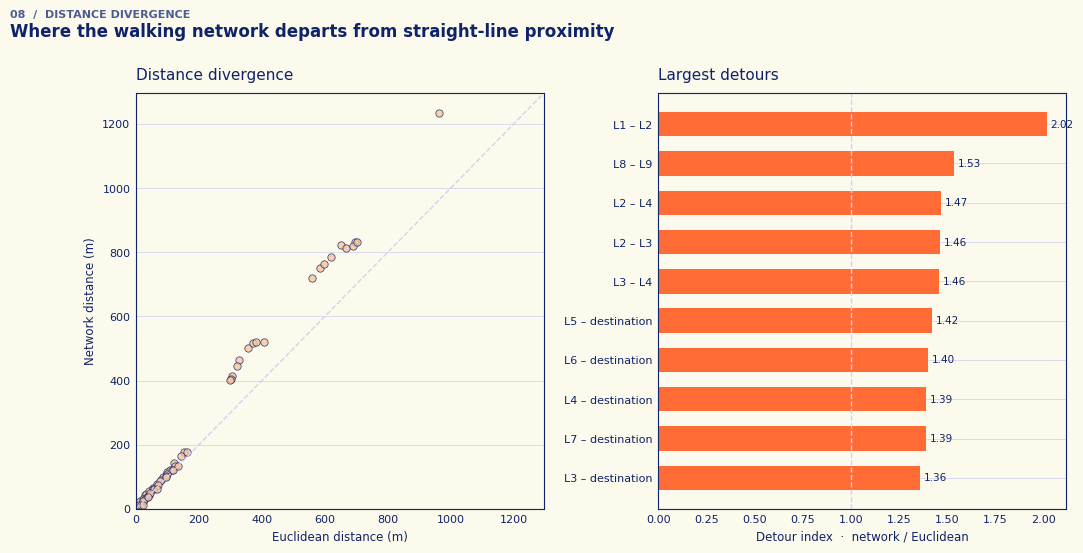

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4), gridspec_kw={"wspace": 0.28})
ax = axes[0]
valid = compare_df.dropna(subset=["euclidean_m", "network_m"]).copy()
ax.scatter(
    valid.euclidean_m,
    valid.network_m,
    s=28,
    facecolor=AMBER_LIGHT,
    edgecolor=DARK,
    linewidth=0.6,
    alpha=0.78,
)
lims = [0, max(valid.euclidean_m.max(), valid.network_m.max()) * 1.05]
ax.plot(lims, lims, color=BLUE_PALE, lw=1.0, linestyle="--")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Euclidean distance (m)")
ax.set_ylabel("Network distance (m)")
ax.set_title("Distance divergence", loc="left", pad=10)
style_ax(ax, grid=True)
ax = axes[1]
top = compare_df.head(10).copy()
top["pair"] = top.node_a + " – " + top.node_b
ax.barh(top.pair, top.detour_index, color=AMBER, height=0.62)
ax.invert_yaxis()
ax.axvline(1, color=BLUE_PALE, lw=1.0, linestyle="--")
ax.set_xlabel("Detour index  ·  network / Euclidean")
ax.set_title("Largest detours", loc="left", pad=10)
style_ax(ax, grid=True)
for idx, value in enumerate(top.detour_index):
    ax.text(value + 0.02, idx, f"{value:.2f}", va="center", fontsize=7.5, color=DARK)
fig.text(
    0.02, 1.02, "08  /  DISTANCE DIVERGENCE", fontsize=8, color=LABEL, fontweight="bold"
)
fig.text(
    0.02,
    0.985,
    "Where the walking network departs from straight-line proximity",
    fontsize=12,
    color=DARK,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## 8b. Along the actual commute route: adjacent vs. end-to-end

The 9 lamp nodes aren't independent points — they sit in order along one
trail you actually walk. Two comparisons matter here:

- **Adjacent lamps** (L1–L2, L2–L3, …): consecutive points close together
  on a locally near-straight stretch. Expect the detour index close to 1.
- **End-to-end** (L1 to L9): the full stretch of your commute route through
  the park. Morningside Park sits on a bluff with stairs and switchbacks,
  so expect a much larger detour index here even though the straight-line
  distance isn't that much bigger than a single block.

I also chart cumulative distance along the sequence — Euclidean (straight
line from the start) vs. network (actual walked distance) — to show how
the gap between the two compounds as you move through the park.


In [16]:
lamp_seq = lamps_gdf.sort_values("sequence").reset_index(drop=True)
lamp_ids_ordered = lamp_seq["id"].tolist()

adjacent_rows = []
for i in range(len(lamp_ids_ordered) - 1):
    a, b = lamp_ids_ordered[i], lamp_ids_ordered[i + 1]
    adjacent_rows.append(
        {
            "segment": f"{a}\u2013{b}",
            "euclidean_m": euclid_df.loc[a, b],
            "network_m": network_matrix.loc[a, b],
        }
    )
adjacent_df = pd.DataFrame(adjacent_rows)
adjacent_df["detour_index"] = adjacent_df.network_m / adjacent_df.euclidean_m

end_to_end = compare_df[
    (
        (compare_df.node_a == lamp_ids_ordered[0])
        & (compare_df.node_b == lamp_ids_ordered[-1])
    )
    | (
        (compare_df.node_a == lamp_ids_ordered[-1])
        & (compare_df.node_b == lamp_ids_ordered[0])
    )
]

print("Adjacent-lamp segments:")
display(adjacent_df)
print("\nEnd-to-end (first lamp to last lamp):")
display(end_to_end)

Adjacent-lamp segments:


,segment,euclidean_m,network_m,detour_index
0,L1–L2,12.915948,26.055409,2.017305
1,L2–L3,9.257643,13.556586,1.464367
2,L3–L4,21.539209,31.442545,1.459782
3,L4–L5,26.402875,27.788155,1.052467
4,L5–L6,34.390106,37.541472,1.091636
5,L6–L7,23.661286,23.373778,0.987849
6,L7–L8,15.734058,12.346743,0.784714
7,L8–L9,27.925241,42.838110,1.534028



End-to-end (first lamp to last lamp):


,node_a,node_b,euclidean_m,network_m,detour_index
7,L1,L9,160.889735,176.665255,1.098052


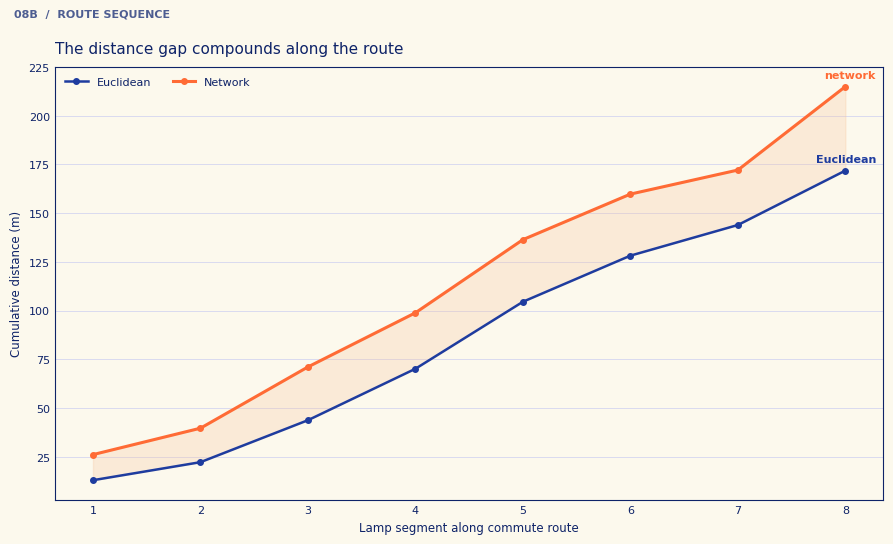

In [17]:
adjacent_df["cum_euclidean_m"] = adjacent_df.euclidean_m.cumsum()
adjacent_df["cum_network_m"] = adjacent_df.network_m.cumsum()
fig, ax = plt.subplots(figsize=(9, 5.2))
x = np.arange(1, len(adjacent_df) + 1)
ax.plot(
    x,
    adjacent_df.cum_euclidean_m,
    color=BLUE,
    lw=1.8,
    marker="o",
    ms=4,
    label="Euclidean",
)
ax.plot(
    x, adjacent_df.cum_network_m, color=AMBER, lw=2.2, marker="o", ms=4, label="Network"
)
ax.fill_between(
    x,
    adjacent_df.cum_euclidean_m,
    adjacent_df.cum_network_m,
    color=AMBER_LIGHT,
    alpha=0.28,
)
ax.set_xticks(x)
ax.set_xticklabels([str(i) for i in x])
ax.set_xlabel("Lamp segment along commute route")
ax.set_ylabel("Cumulative distance (m)")
ax.set_title("The distance gap compounds along the route", loc="left", pad=10)
style_ax(ax, grid=True)
ax.legend(frameon=False, ncol=2, loc="upper left")
ax.annotate(
    "network",
    (x[-1], adjacent_df.cum_network_m.iloc[-1]),
    xytext=(-15, 8),
    textcoords="offset points",
    va="center",
    color=AMBER,
    fontsize=8,
    fontweight="bold",
)
ax.annotate(
    "Euclidean",
    (x[-1], adjacent_df.cum_euclidean_m.iloc[-1]),
    xytext=(-21, 8),
    textcoords="offset points",
    va="center",
    color=BLUE,
    fontsize=8,
    fontweight="bold",
)
fig.text(
    0.02, 1.02, "08B  /  ROUTE SEQUENCE", fontsize=8, color=LABEL, fontweight="bold"
)
plt.tight_layout()
plt.show()

## 8c. Full commute: Columbia campus to Cathedral Pkwy station

A separate origin-destination comparison, independent of the 9-lamp
trail: the straight-line vs. actual-walked distance between the origin
and destination points defined in Section 3c. This walk runs along
Broadway/Manhattan Ave rather than through Morningside Park itself, so
it's a useful baseline for how much detour a fairly direct street-grid
walk adds compared to the terrain-constrained park route above.


Columbia University (116th St & Broadway)  ->  Cathedral Pkwy–110th St subway station (B/C train)


,node_a,node_b,euclidean_m,network_m,detour_index
54,origin,destination,962.69223,1234.149833,1.281978


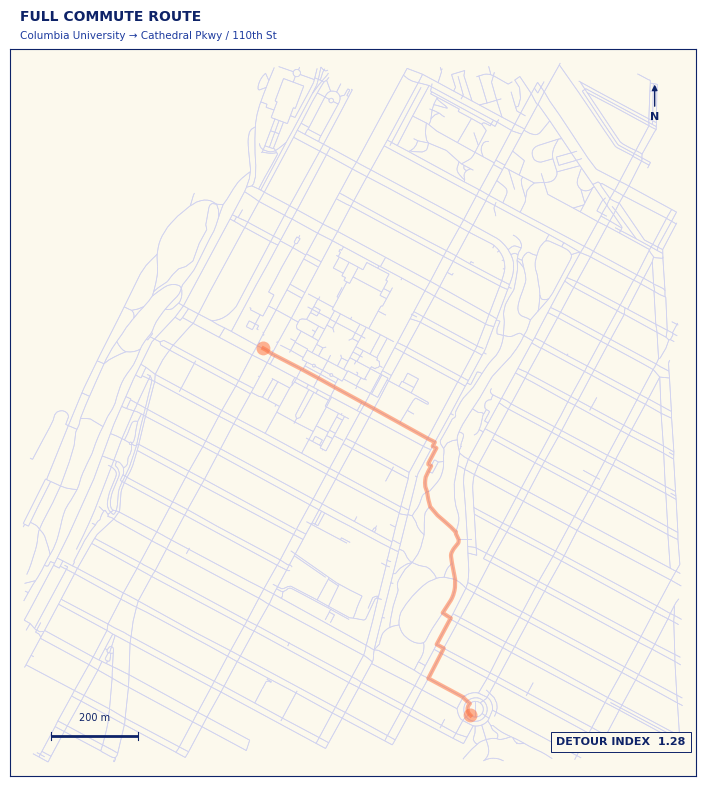

In [18]:
origin_dest_pair = compare_df[
    ((compare_df.node_a == "origin") & (compare_df.node_b == "destination"))
    | ((compare_df.node_a == "destination") & (compare_df.node_b == "origin"))
]
print(f"{ORIGIN_NAME}  ->  {DEST_NAME}")
display(origin_dest_pair)
origin_node = node_lookup["origin"]
dest_node = node_lookup["destination"]
route = nx.shortest_path(G_proj, origin_node, dest_node, weight="length")
fig, ax = ox.plot_graph_route(
    G_proj,
    route,
    route_color=AMBER,
    route_linewidth=3.0,
    node_size=0,
    edge_color=BLUE_PALE,
    edge_linewidth=0.55,
    bgcolor=PAPER,
    show=False,
    close=False,
)
detour = (
    origin_dest_pair.detour_index.iloc[0] if len(origin_dest_pair) else float("nan")
)
style_map(ax, "Full commute route", "Columbia University → Cathedral Pkwy / 110th St")
add_north_arrow(ax)
add_scale_bar(ax, length_m=200)
ax.text(
    0.985,
    0.04,
    f"DETOUR INDEX  {detour:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8,
    color=DARK,
    fontweight="bold",
    bbox=dict(
        boxstyle="square,pad=0.45", facecolor=PAPER, edgecolor=DARK, linewidth=0.7
    ),
)
plt.tight_layout(pad=1.5)
plt.show()

## 9. Map the shortest walking route for the largest detours

Visualizing the actual path taken for the pairs with the highest detour
index shows *why* the network distance is so much longer than the
straight-line gap — helpful for connecting back to the lighting/visibility
narrative.


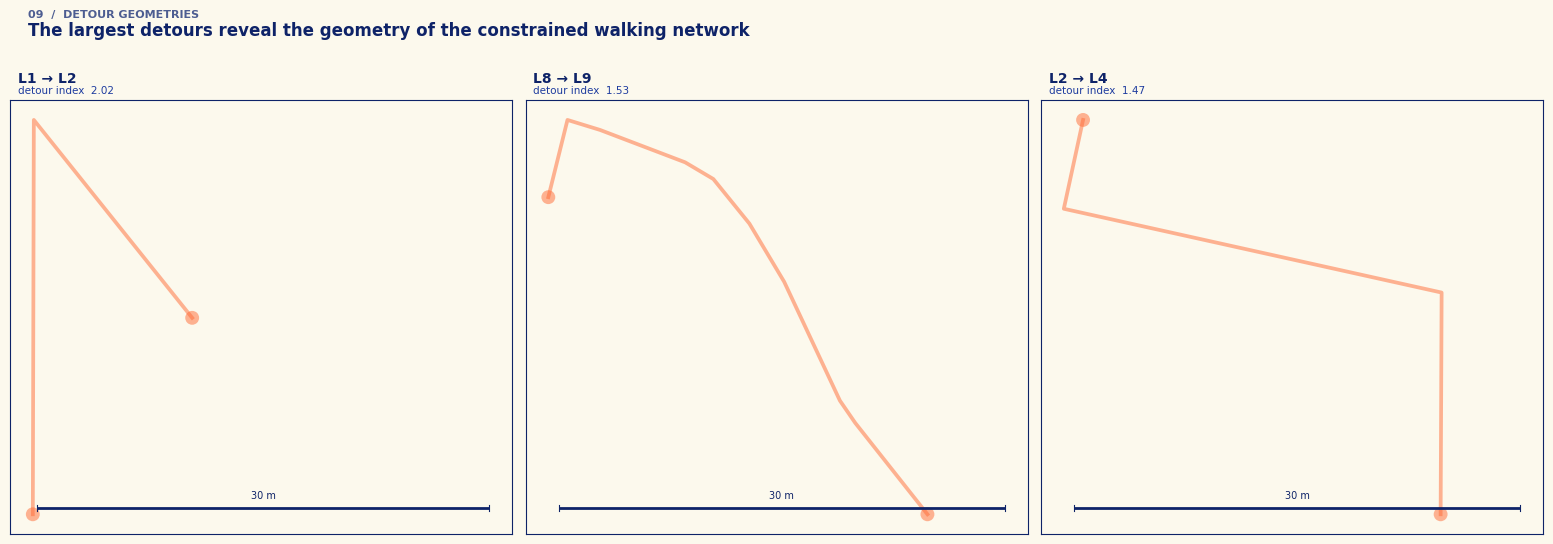

In [19]:
top_pairs = compare_df.head(3)
fig, axes = plt.subplots(
    1, len(top_pairs), figsize=(5.2 * len(top_pairs), 5.2), squeeze=False
)
axes = axes.ravel()
for ax, (_, row) in zip(axes, top_pairs.iterrows()):
    origin = node_lookup[row.node_a]
    dest = node_lookup[row.node_b]
    route = nx.shortest_path(G_proj, origin, dest, weight="length")
    ox.plot_graph_route(
        G_proj,
        route,
        route_color=AMBER,
        route_linewidth=2.7,
        node_size=0,
        edge_color=BLUE_LIGHT,
        edge_linewidth=0.5,
        bgcolor=PAPER,
        ax=ax,
        show=False,
        close=False,
    )
    style_map(
        ax, f"{row.node_a} → {row.node_b}", f"detour index  {row.detour_index:.2f}"
    )
    add_scale_bar(ax, length_m=30, x=0.07, y=0.06)
fig.text(
    0.02, 1.02, "09  /  DETOUR GEOMETRIES", fontsize=8, color=LABEL, fontweight="bold"
)
fig.text(
    0.02,
    0.985,
    "The largest detours reveal the geometry of the constrained walking network",
    fontsize=12,
    color=DARK,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## 10. Actual walked route vs. modeled shortest path

The earlier sections establish what the pedestrian network makes possible. This section asks a different question: **what happens when the route a person actually walks is compared with the distance-optimal route produced by the network model?**

The actual route comes from `actual_route.geojson`, a GPS-traced/hand-cleaned record of the commute with 29 vertices. It is compared against the modeled shortest path between the same origin and destination on the same walking network. The modeled route is **not a Google Maps recommendation**; it is the route that minimizes network distance in this notebook using the mapped pedestrian network and Dijkstra's algorithm. It is best understood as a distance-optimal benchmark.

The comparison is useful because a real pedestrian does not necessarily optimize distance alone. The actual route may reflect factors that are not represented in the current network cost, such as lighting, sightlines, familiarity, perceived safety, comfort with stairs, or preferred entrances and exits. This analysis does not prove which factor caused the deviation; it identifies where the observed route departs from the distance-only benchmark so those factors can be tested later.

The route endpoints are aligned to the same origin and destination used elsewhere in the notebook so that the three-route comparison remains consistent.


Euclidean (straight-line):        962.7 m
Modeled shortest path:           1234.1 m
Actual walked route (GPS):       1296.0 m

Actual walked route is +61.8 m (+5.0%) vs. the computed 'optimal' shortest path.

Routes diverge by >8 m at 25 traced points (max divergence: 117.2 m)


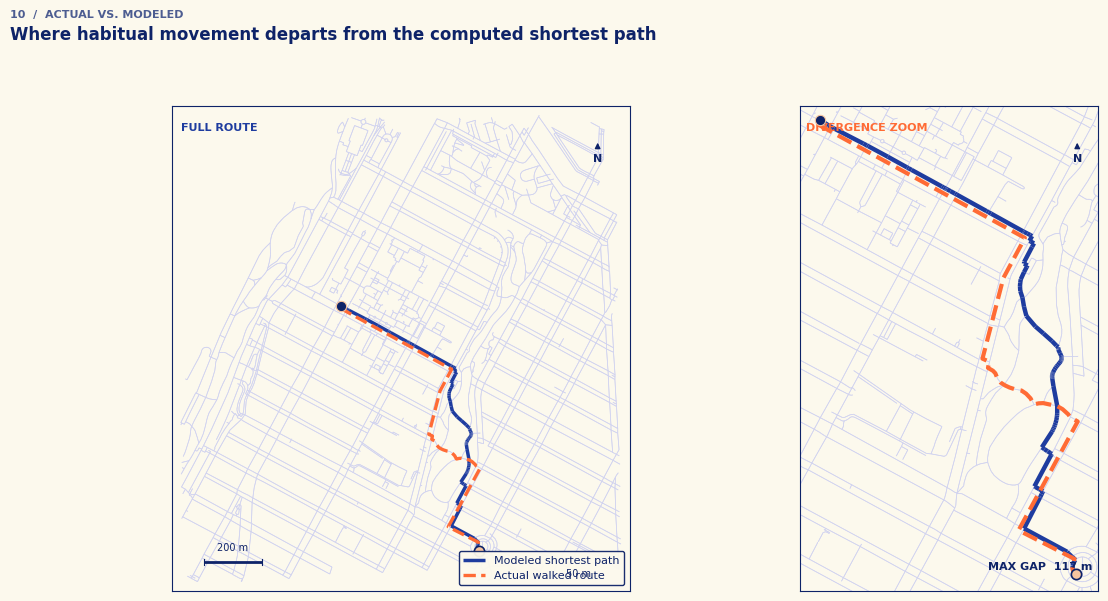

In [21]:
actual_route_gdf = gpd.read_file("./data/actual_route.geojson")
actual_line_wgs84 = actual_route_gdf[
    actual_route_gdf.geometry.type == "LineString"
].geometry.iloc[0]

# project the traced route into the same metric CRS as the walking graph
actual_line_proj = (
    gpd.GeoSeries([actual_line_wgs84], crs="EPSG:4326").to_crs(edges_gdf.crs).iloc[0]
)
actual_route_length_m = actual_line_proj.length

modeled_route_length_m = origin_dest_pair.network_m.iloc[0]
euclidean_length_m = origin_dest_pair.euclidean_m.iloc[0]

print(f"Euclidean (straight-line):     {euclidean_length_m:8.1f} m")
print(f"Modeled shortest path:         {modeled_route_length_m:8.1f} m")
print(f"Actual walked route (GPS):     {actual_route_length_m:8.1f} m")
print(
    f"\nActual walked route is {actual_route_length_m - modeled_route_length_m:+.1f} m "
    f"({(actual_route_length_m / modeled_route_length_m - 1) * 100:+.1f}%) "
    "vs. the computed 'optimal' shortest path."
)

# ---- find where the two routes actually diverge ----
from shapely.ops import linemerge
from shapely.geometry import Point

route = nx.shortest_path(G_proj, origin_node, dest_node, weight="length")
route_edges = ox.routing.route_to_gdf(G_proj, route)
modeled_line_proj = linemerge(route_edges.geometry.tolist())
if modeled_line_proj.geom_type == "MultiLineString":
    modeled_line_proj = linemerge(list(modeled_line_proj.geoms))

sample_pts = [Point(xy) for xy in actual_line_proj.coords]
dists_to_modeled = [modeled_line_proj.distance(p) for p in sample_pts]
DIVERGE_THRESHOLD_M = 8
diverge_idxs = [i for i, d in enumerate(dists_to_modeled) if d > DIVERGE_THRESHOLD_M]

if diverge_idxs:
    lo = max(0, min(diverge_idxs) - 2)
    hi = min(len(sample_pts) - 1, max(diverge_idxs) + 2)
    zoom_xs = [sample_pts[i].x for i in range(lo, hi + 1)]
    zoom_ys = [sample_pts[i].y for i in range(lo, hi + 1)]
    pad = 35
    zoom_bounds = (
        min(zoom_xs) - pad,
        max(zoom_xs) + pad,
        min(zoom_ys) - pad,
        max(zoom_ys) + pad,
    )
    print(
        f"\nRoutes diverge by >{DIVERGE_THRESHOLD_M} m at {len(diverge_idxs)} traced points "
        f"(max divergence: {max(dists_to_modeled):.1f} m)"
    )
else:
    zoom_bounds = None
    print("\nNo divergence beyond threshold found -- routes are effectively identical.")

# ---- two-panel figure: full context + zoomed divergence ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 6.3), gridspec_kw={"wspace": 0.10})
for ax, is_zoom in [(ax1, False), (ax2, True)]:
    ox.plot_graph(
        G_proj,
        ax=ax,
        node_size=0,
        edge_color=BLUE_PALE,
        edge_linewidth=0.5,
        bgcolor=PAPER,
        show=False,
        close=False,
    )
    route_edges.plot(
        ax=ax,
        color=BLUE,
        linewidth=3.2 if is_zoom else 2.5,
        zorder=3,
        label="Modeled shortest path",
    )
    gpd.GeoSeries([actual_line_proj]).plot(
        ax=ax,
        color=AMBER,
        linewidth=3.0 if is_zoom else 2.4,
        linestyle="--",
        zorder=4,
        label="Actual walked route",
    )
    origin_geom = nodes_gdf.loc[origin_node].geometry
    dest_geom = nodes_gdf.loc[dest_node].geometry
    ax.scatter(
        [origin_geom.x],
        [origin_geom.y],
        c=DARK,
        s=55,
        edgecolors=AMBER_LIGHT,
        linewidths=0.8,
        zorder=5,
    )
    ax.scatter(
        [dest_geom.x],
        [dest_geom.y],
        facecolors=AMBER_LIGHT,
        edgecolors=DARK,
        s=55,
        linewidths=1.2,
        zorder=5,
    )
    style_map(ax)
    add_north_arrow(ax, x=0.93, y=0.88, size=0.05)
    add_scale_bar(ax, length_m=200 if not is_zoom else 50, x=0.07, y=0.06)
ax1.text(
    0.02,
    0.965,
    "FULL ROUTE",
    transform=ax1.transAxes,
    fontsize=8,
    color=BLUE,
    fontweight="bold",
    va="top",
)
ax2.text(
    0.02,
    0.965,
    "DIVERGENCE ZOOM",
    transform=ax2.transAxes,
    fontsize=8,
    color=AMBER,
    fontweight="bold",
    va="top",
)
ax1.legend(
    loc="lower right", frameon=True, facecolor=PAPER, edgecolor=DARK, framealpha=0.95
)
if zoom_bounds:
    x0, x1, y0, y1 = zoom_bounds
    ax2.set_xlim(x0, x1)
    ax2.set_ylim(y0, y1)
    ax2.text(
        0.98,
        0.04,
        f"MAX GAP  {max(dists_to_modeled):.0f} m",
        transform=ax2.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        color=DARK,
        fontweight="bold",
    )
else:
    ax2.text(
        0.98,
        0.04,
        "NO SIGNIFICANT DIVERGENCE",
        transform=ax2.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        color=DARK,
        fontweight="bold",
    )
fig.text(
    0.02, 1.02, "10  /  ACTUAL VS. MODELED", fontsize=8, color=LABEL, fontweight="bold"
)
fig.text(
    0.02,
    0.985,
    "Where habitual movement departs from the computed shortest path",
    fontsize=12,
    color=DARK,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(
    "actual_vs_modeled_route.png", dpi=240, bbox_inches="tight", facecolor=PAPER
)
plt.show()

Euclidean (straight-line):        962.7 m
Modeled shortest path:           1234.1 m
Actual walked route (GPS):       1296.0 m

Actual walked route is +61.8 m (+5.0%) vs. the computed 'optimal' shortest path.

Routes diverge by >8 m at 25 traced points (max spatial gap: 117.2 m)


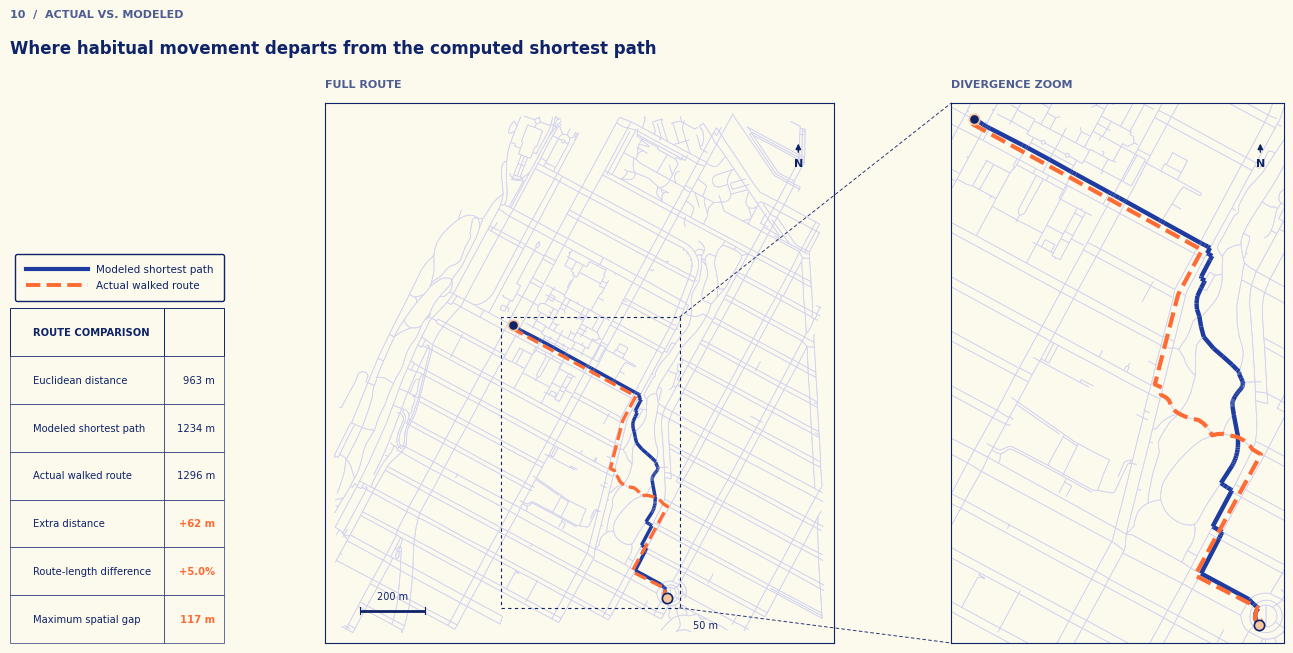

In [22]:
actual_route_gdf = gpd.read_file("./data/actual_route.geojson")
actual_line_wgs84 = actual_route_gdf[
    actual_route_gdf.geometry.type == "LineString"
].geometry.iloc[0]

# project the traced route into the same metric CRS as the walking graph
actual_line_proj = (
    gpd.GeoSeries([actual_line_wgs84], crs="EPSG:4326").to_crs(edges_gdf.crs).iloc[0]
)
actual_route_length_m = actual_line_proj.length

modeled_route_length_m = origin_dest_pair.network_m.iloc[0]
euclidean_length_m = origin_dest_pair.euclidean_m.iloc[0]

print(f"Euclidean (straight-line):     {euclidean_length_m:8.1f} m")
print(f"Modeled shortest path:         {modeled_route_length_m:8.1f} m")
print(f"Actual walked route (GPS):     {actual_route_length_m:8.1f} m")
print(
    f"\nActual walked route is {actual_route_length_m - modeled_route_length_m:+.1f} m "
    f"({(actual_route_length_m / modeled_route_length_m - 1) * 100:+.1f}%) "
    "vs. the computed 'optimal' shortest path."
)

# find where the two routes actually diverge
from shapely.ops import linemerge
from shapely.geometry import Point
from matplotlib.patches import Rectangle, ConnectionPatch
from matplotlib.lines import Line2D

# Recompute the origin-to-destination shortest route explicitly so Section 9
# cannot overwrite it with one of the short lamp-to-lamp routes.
route = nx.shortest_path(G_proj, origin_node, dest_node, weight="length")
route_edges = ox.routing.route_to_gdf(G_proj, route)
modeled_line_proj = linemerge(route_edges.geometry.tolist())
if modeled_line_proj.geom_type == "MultiLineString":
    modeled_line_proj = linemerge(list(modeled_line_proj.geoms))

sample_pts = [Point(xy) for xy in actual_line_proj.coords]
dists_to_modeled = [modeled_line_proj.distance(p) for p in sample_pts]
DIVERGE_THRESHOLD_M = 8
diverge_idxs = [i for i, d in enumerate(dists_to_modeled) if d > DIVERGE_THRESHOLD_M]

if diverge_idxs:
    lo = max(0, min(diverge_idxs) - 2)
    hi = min(len(sample_pts) - 1, max(diverge_idxs) + 2)
    zoom_xs = [sample_pts[i].x for i in range(lo, hi + 1)]
    zoom_ys = [sample_pts[i].y for i in range(lo, hi + 1)]
    pad = 35
    zoom_bounds = (
        min(zoom_xs) - pad,
        max(zoom_xs) + pad,
        min(zoom_ys) - pad,
        max(zoom_ys) + pad,
    )
    max_gap_m = max(dists_to_modeled)
    print(
        f"\nRoutes diverge by >{DIVERGE_THRESHOLD_M} m at {len(diverge_idxs)} traced points "
        f"(max spatial gap: {max_gap_m:.1f} m)"
    )
else:
    zoom_bounds = None
    max_gap_m = max(dists_to_modeled) if dists_to_modeled else float("nan")
    print("\nNo divergence beyond threshold found -- routes are effectively identical.")

# ============================================================
# FIGURE 10 — ACTUAL VS. MODELED
# Editorial map plate inspired by the reference guide:
# left information column + full route + divergence detail.
# ============================================================
fig = plt.figure(figsize=(13.8, 7.5), facecolor=PAPER)

# Fixed positions give us the clean architectural-plate composition.
ax_info = fig.add_axes([0.045, 0.12, 0.155, 0.72])
ax1 = fig.add_axes([0.245, 0.12, 0.425, 0.72])
ax2 = fig.add_axes([0.720, 0.12, 0.255, 0.72])
ax_info.axis("off")

# ---- shared map styling ----
for ax, is_zoom in [(ax1, False), (ax2, True)]:
    ox.plot_graph(
        G_proj,
        ax=ax,
        node_size=0,
        edge_color=BLUE_PALE,
        edge_linewidth=0.5,
        bgcolor=PAPER,
        show=False,
        close=False,
    )

    route_edges.plot(
        ax=ax,
        color=BLUE,
        linewidth=3.2 if is_zoom else 2.5,
        zorder=3,
    )

    gpd.GeoSeries([actual_line_proj]).plot(
        ax=ax,
        color=AMBER,
        linewidth=3.0 if is_zoom else 2.4,
        linestyle="--",
        zorder=4,
    )

    origin_geom = nodes_gdf.loc[origin_node].geometry
    dest_geom = nodes_gdf.loc[dest_node].geometry

    ax.scatter(
        [origin_geom.x],
        [origin_geom.y],
        c=DARK,
        s=55,
        edgecolors=AMBER_LIGHT,
        linewidths=1.2,
        zorder=5,
    )
    ax.scatter(
        [dest_geom.x],
        [dest_geom.y],
        facecolors=AMBER_LIGHT,
        edgecolors=DARK,
        s=55,
        linewidths=1.2,
        zorder=5,
    )

    style_map(ax)
    add_north_arrow(ax, x=0.93, y=0.88, size=0.05)
    add_scale_bar(
        ax,
        length_m=200 if not is_zoom else 50,
        x=0.07,
        y=0.06,
    )

# ---- map labels ----
ax1.text(
    0.00,
    1.025,
    "FULL ROUTE",
    transform=ax1.transAxes,
    fontsize=8,
    color=LABEL,
    fontweight="bold",
    va="bottom",
)
ax2.text(
    0.00,
    1.025,
    "DIVERGENCE ZOOM",
    transform=ax2.transAxes,
    fontsize=8,
    color=LABEL,
    fontweight="bold",
    va="bottom",
)

# ---- zoom extent + locator rectangle + connector lines ----
if zoom_bounds:
    x0, x1, y0, y1 = zoom_bounds
    ax2.set_xlim(x0, x1)
    ax2.set_ylim(y0, y1)

    # Locator rectangle on the full-route map.
    locator = Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        fill=False,
        edgecolor=DARK,
        linewidth=0.8,
        linestyle=(0, (3, 3)),
        zorder=6,
    )
    ax1.add_patch(locator)

    # Two restrained locator lines, matching the reference-guide logic.
    con_top = ConnectionPatch(
        xyA=(x1, y1),
        coordsA=ax1.transData,
        xyB=(0.00, 1.00),
        coordsB=ax2.transAxes,
        color=DARK,
        linewidth=0.7,
        linestyle=(0, (3, 3)),
        alpha=0.9,
        zorder=2,
    )
    con_bottom = ConnectionPatch(
        xyA=(x1, y0),
        coordsA=ax1.transData,
        xyB=(0.00, 0.00),
        coordsB=ax2.transAxes,
        color=DARK,
        linewidth=0.7,
        linestyle=(0, (3, 3)),
        alpha=0.9,
        zorder=2,
    )
    fig.add_artist(con_top)
    fig.add_artist(con_bottom)

# ---- left information column: legend ----
legend_handles = [
    Line2D([0], [0], color=BLUE, lw=3.0, label="Modeled shortest path"),
    Line2D([0], [0], color=AMBER, lw=2.8, linestyle="--", label="Actual walked route"),
]
leg = ax_info.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(0.0, 0.73),
    frameon=True,
    facecolor=PAPER,
    edgecolor=DARK,
    framealpha=1.0,
    fontsize=7.5,
    handlelength=6.0,
    borderpad=1.0,
    labelspacing=0.6,
)

# ---- left information column: quantitative comparison table ----
actual_delta_m = actual_route_length_m - modeled_route_length_m
actual_delta_pct = (actual_route_length_m / modeled_route_length_m - 1) * 100

rows = [
    ("Euclidean distance", f"{euclidean_length_m:.0f} m"),
    ("Modeled shortest path", f"{modeled_route_length_m:.0f} m"),
    ("Actual walked route", f"{actual_route_length_m:.0f} m"),
    ("Extra distance", f"+{actual_delta_m:.0f} m"),
    ("Route-length difference", f"+{actual_delta_pct:.1f}%"),
    ("Maximum spatial gap", f"{max_gap_m:.0f} m"),
]

table = ax_info.table(
    cellText=[[label, value] for label, value in rows],
    colLabels=["ROUTE COMPARISON", ""],
    colWidths=[0.80, 0.31],
    cellLoc="left",
    colLoc="left",
    bbox=[0.0, 0.0, 1.0, 0.62],
)
table.auto_set_font_size(False)
table.set_fontsize(7.2)

for (r, c), cell in table.get_celld().items():
    cell.set_facecolor(PAPER)
    cell.set_edgecolor(DARK)
    cell.set_linewidth(0.45)
    cell.PAD = 0.15
    cell.get_text().set_color(DARK)
    if r == 0:
        cell.get_text().set_fontweight("bold")
        cell.get_text().set_color(DARK)
        cell.set_edgecolor(DARK)
        cell.set_linewidth(0.7)
    elif c == 1:
        cell.get_text().set_ha("right")
        if r in (4, 5, 6):
            cell.get_text().set_fontweight("bold")
            cell.get_text().set_color(AMBER)

# ---- figure heading ----
fig.text(
    0.045,
    0.965,
    "10  /  ACTUAL VS. MODELED",
    fontsize=8,
    color=LABEL,
    fontweight="bold",
    va="top",
)
fig.text(
    0.045,
    0.925,
    "Where habitual movement departs from the computed shortest path",
    fontsize=12,
    color=DARK,
    fontweight="bold",
    va="top",
)

plt.savefig(
    "actual_vs_modeled_route.png",
    dpi=240,
    bbox_inches="tight",
    facecolor=PAPER,
)
plt.show()

,route,distance_m,detour_vs_euclidean,time_typical_min,time_cautious_min
0,Euclidean (straight-line),962.69,1.00,11.46,14.59
1,Modeled shortest path,1234.15,1.28,14.69,18.70
2,Actual walked route (GPS),1296.00,1.35,15.43,19.64


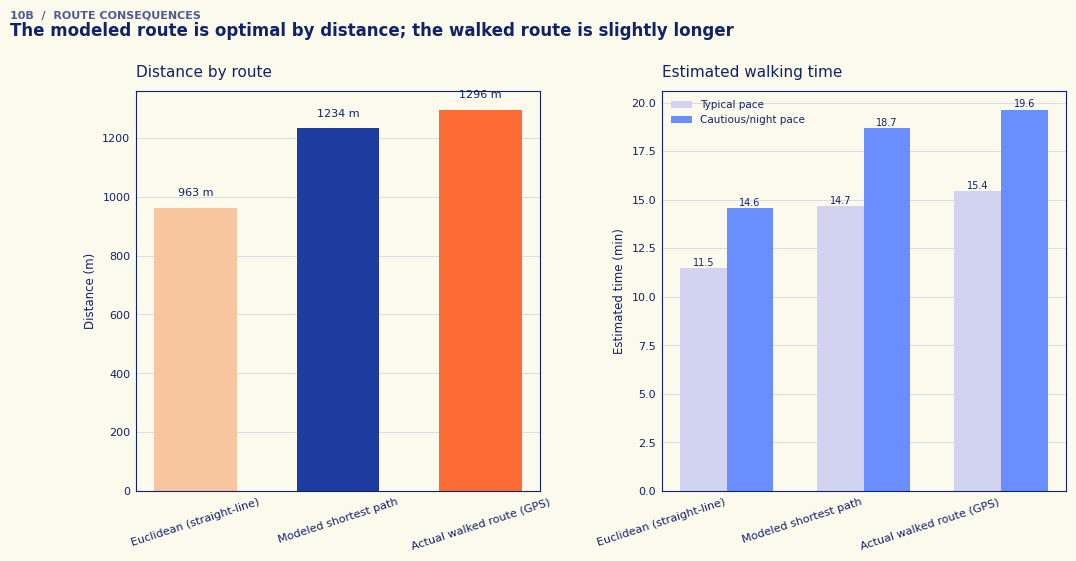

In [23]:
# ---- expected time for each route, at two pace assumptions ----
TYPICAL_PACE_MPS = 1.4
CAUTIOUS_PACE_MPS = 1.1

route_comparison = pd.DataFrame(
    {
        "route": [
            "Euclidean (straight-line)",
            "Modeled shortest path",
            "Actual walked route (GPS)",
        ],
        "distance_m": [
            euclidean_length_m,
            modeled_route_length_m,
            actual_route_length_m,
        ],
    }
)
route_comparison["detour_vs_euclidean"] = (
    route_comparison.distance_m / euclidean_length_m
)
route_comparison["time_typical_min"] = (
    route_comparison.distance_m / TYPICAL_PACE_MPS / 60
)
route_comparison["time_cautious_min"] = (
    route_comparison.distance_m / CAUTIOUS_PACE_MPS / 60
)
route_comparison = route_comparison.round(2)
display(route_comparison)

# ---- editorial comparison: distance + estimated time ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), gridspec_kw={"wspace": 0.30})
ax = axes[0]
bars = ax.bar(
    route_comparison.route,
    route_comparison.distance_m,
    color=[AMBER_LIGHT, BLUE, AMBER],
    width=0.58,
)
ax.set_ylabel("Distance (m)")
ax.set_title("Distance by route", loc="left", pad=10)
ax.tick_params(axis="x", rotation=18)
style_ax(ax, grid=True)
for bar, val in zip(bars, route_comparison.distance_m):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + route_comparison.distance_m.max() * 0.025,
        f"{val:.0f} m",
        ha="center",
        va="bottom",
        fontsize=8,
        color=DARK,
    )
ax = axes[1]
x = np.arange(len(route_comparison))
width = 0.34
b1 = ax.bar(
    x - width / 2,
    route_comparison.time_typical_min,
    width,
    color=BLUE_PALE,
    label="Typical pace",
)
b2 = ax.bar(
    x + width / 2,
    route_comparison.time_cautious_min,
    width,
    color=BLUE_LIGHT,
    label="Cautious/night pace",
)
ax.set_xticks(x)
ax.set_xticklabels(route_comparison.route, rotation=18, ha="right")
ax.set_ylabel("Estimated time (min)")
ax.set_title("Estimated walking time", loc="left", pad=10)
style_ax(ax, grid=True)
ax.legend(frameon=False, fontsize=7.5, loc="upper left")
for group in [b1, b2]:
    for bar in group:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{bar.get_height():.1f}",
            ha="center",
            va="bottom",
            fontsize=7,
            color=DARK,
        )
fig.text(
    0.02, 1.02, "10B  /  ROUTE CONSEQUENCES", fontsize=8, color=LABEL, fontweight="bold"
)
fig.text(
    0.02,
    0.985,
    "The modeled route is optimal by distance; the walked route is slightly longer",
    fontsize=12,
    color=DARK,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("route_time_comparison.png", dpi=240, bbox_inches="tight", facecolor=PAPER)
plt.show()

**The actual walked route is 5.0% (61 m) longer than the modeled
'optimal' shortest path**, and about 35% longer than straight-line
distance. At a typical walking pace that's roughly 44 extra seconds versus
the modeled route; at a more cautious nighttime pace, about 56 extra
seconds — small in absolute terms, but real, and it means the shortest-path
model is systematically optimistic about this commute.

# 10C. Where does the actual route diverge?

The maximum spatial gap is useful, but it is only one point. This profile shows **where the actual route separates from the modeled shortest path and how that separation changes along the commute**.

The x-axis follows distance traveled along the actual route; the y-axis measures the shortest spatial distance from each actual-route point to the modeled path. A brief spike and a sustained separation tell different stories, so the profile helps distinguish between them.


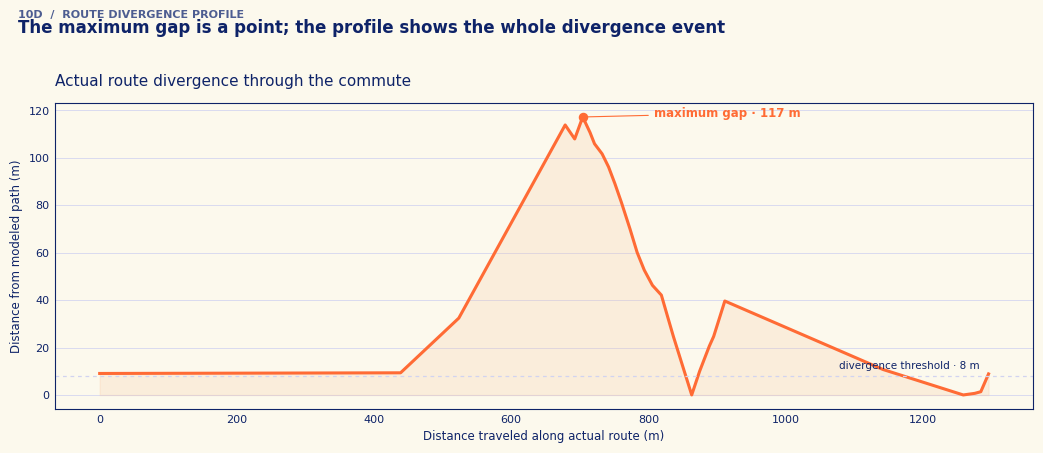

In [24]:
# ---- divergence profile along the actual route ----
actual_coords = list(actual_line_proj.coords)
profile_distance_m = []
profile_gap_m = []

for xy in actual_coords:
    pt = Point(xy)
    profile_distance_m.append(actual_line_proj.project(pt))
    profile_gap_m.append(modeled_line_proj.distance(pt))

profile_distance_m = np.asarray(profile_distance_m)
profile_gap_m = np.asarray(profile_gap_m)
max_idx = int(np.argmax(profile_gap_m))
max_gap_profile = profile_gap_m[max_idx]
max_pos_profile = profile_distance_m[max_idx]

fig, ax = plt.subplots(figsize=(10.5, 4.3))
ax.plot(profile_distance_m, profile_gap_m, color=AMBER, lw=2.2)
ax.fill_between(profile_distance_m, profile_gap_m, 0, color=AMBER_LIGHT, alpha=0.22)
ax.axhline(DIVERGE_THRESHOLD_M, color=BLUE_PALE, lw=0.9, ls=(0, (3, 3)))
ax.text(
    profile_distance_m[-1] * 0.99,
    DIVERGE_THRESHOLD_M + 2,
    f"divergence threshold · {DIVERGE_THRESHOLD_M} m",
    ha="right",
    va="bottom",
    fontsize=7.5,
    color=DARK,
)
ax.scatter([max_pos_profile], [max_gap_profile], s=34, color=AMBER, zorder=5)
ax.annotate(
    f"maximum gap · {max_gap_profile:.0f} m",
    xy=(max_pos_profile, max_gap_profile),
    xytext=(max_pos_profile + profile_distance_m[-1] * 0.08, max_gap_profile),
    fontsize=8.5,
    color=AMBER,
    fontweight="bold",
    arrowprops=dict(arrowstyle="-", color=AMBER, lw=0.8),
)
ax.set_xlabel("Distance traveled along actual route (m)")
ax.set_ylabel("Distance from modeled path (m)")
ax.set_title("Actual route divergence through the commute", loc="left", pad=12)
style_ax(ax, grid=True)
fig.text(
    0.02,
    1.02,
    "10D  /  ROUTE DIVERGENCE PROFILE",
    fontsize=8,
    color=LABEL,
    fontweight="bold",
)
fig.text(
    0.02,
    0.985,
    "The maximum gap is a point; the profile shows the whole divergence event",
    fontsize=12,
    color=DARK,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(
    "route_divergence_profile.png", dpi=240, bbox_inches="tight", facecolor=PAPER
)
plt.show()

# 10D. Exploratory test: proximity to mapped lamp points

Because this project concerns nighttime pedestrian movement, a useful exploratory question is whether the actual route passes closer to the mapped lamp locations than the distance-optimal alternatives.

This is deliberately framed as **lamp proximity**, not illumination. The current dataset records lamp locations, but does not measure brightness, working condition, obstruction, light coverage, or visibility. A difference here would therefore be a **hypothesis-generating spatial pattern**, not evidence that lighting caused the route choice.


radius_m,15,30,50
route,,,
Actual walked,14.8,18.2,22.3
Euclidean,0.0,0.0,5.3
Modeled shortest,2.7,5.9,9.4


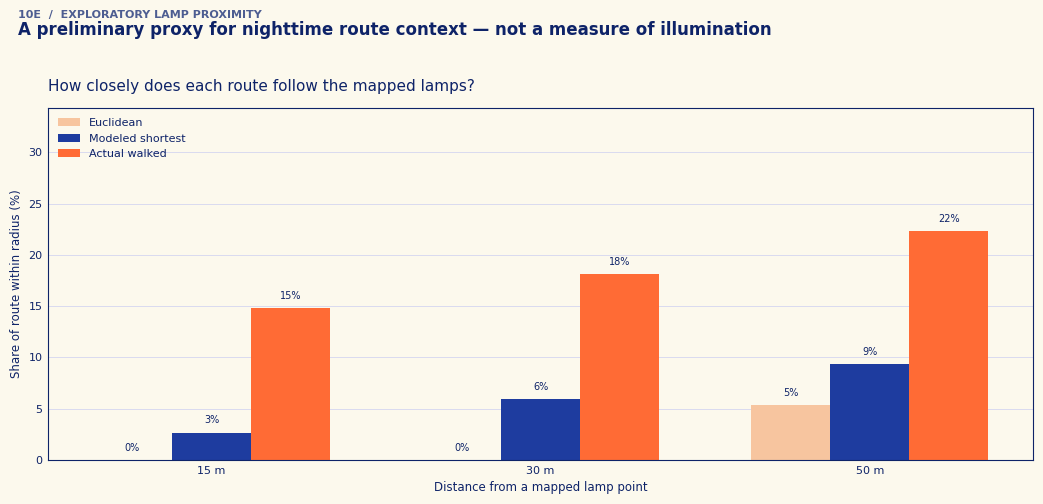

In [25]:
# ---- exploratory lamp-proximity experiment ----
from shapely.geometry import LineString
from shapely.ops import unary_union

lamps_proj = lamps_gdf.to_crs(edges_gdf.crs)
lamp_union = unary_union(list(lamps_proj.geometry))
origin_pt = Point(G_proj.nodes[origin_node]["x"], G_proj.nodes[origin_node]["y"])
dest_pt = Point(G_proj.nodes[dest_node]["x"], G_proj.nodes[dest_node]["y"])
euclidean_line_proj = LineString([origin_pt.coords[0], dest_pt.coords[0]])

experiment_lines = {
    "Euclidean": euclidean_line_proj,
    "Modeled shortest": modeled_line_proj,
    "Actual walked": actual_line_proj,
}

radii_m = [15, 30, 50]
proximity_rows = []
for radius in radii_m:
    corridor = lamp_union.buffer(radius)
    for name, line in experiment_lines.items():
        covered = line.intersection(corridor).length
        proximity_rows.append(
            {
                "route": name,
                "radius_m": radius,
                "share_near_lamp_pct": 100 * covered / line.length,
            }
        )

lamp_proximity_df = pd.DataFrame(proximity_rows)
display(
    lamp_proximity_df.pivot(
        index="route", columns="radius_m", values="share_near_lamp_pct"
    ).round(1)
)

fig, ax = plt.subplots(figsize=(10.5, 4.8))
x = np.arange(len(radii_m))
width = 0.24
for j, (name, color) in enumerate(
    zip(experiment_lines.keys(), [AMBER_LIGHT, BLUE, AMBER])
):
    vals = [
        lamp_proximity_df[
            (lamp_proximity_df.route == name) & (lamp_proximity_df.radius_m == r)
        ].share_near_lamp_pct.iloc[0]
        for r in radii_m
    ]
    bars = ax.bar(x + (j - 1) * width, vals, width=width, color=color, label=name)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.7,
            f"{val:.0f}%",
            ha="center",
            va="bottom",
            fontsize=7,
            color=DARK,
        )

ax.set_xticks(x)
ax.set_xticklabels([f"{r} m" for r in radii_m])
ax.set_xlabel("Distance from a mapped lamp point")
ax.set_ylabel("Share of route within radius (%)")
ax.set_ylim(0, min(100, max(lamp_proximity_df.share_near_lamp_pct.max() + 12, 20)))
ax.set_title("How closely does each route follow the mapped lamps?", loc="left", pad=12)
style_ax(ax, grid=True)
ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.text(
    0.02,
    1.02,
    "10E  /  EXPLORATORY LAMP PROXIMITY",
    fontsize=8,
    color=LABEL,
    fontweight="bold",
)
fig.text(
    0.02,
    0.985,
    "A preliminary proxy for nighttime route context — not a measure of illumination",
    fontsize=12,
    color=DARK,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(
    "lamp_proximity_experiment.png", dpi=240, bbox_inches="tight", facecolor=PAPER
)
plt.show()

# 11. Results & reflection

## What the three-route comparison shows

The full-commute comparison uses three different definitions of distance, and each answers a different question:

1. **Euclidean / straight-line distance** — the simplest spatial baseline. It asks how close the origin and destination are as the crow flies, without accounting for paths, stairs, entrances, or other physical constraints.

2. **Modeled shortest path** — the shortest feasible route through the mapped pedestrian network used in this notebook. It is a **distance-optimal benchmark for this network**, not a claim about what Google Maps would recommend.

3. **Actual walked route** — the observed GPS-traced route taken in practice. It captures a human route choice that may include considerations not represented by distance alone.

For this commute, the actual walked route is **5.0% (61 m) longer than the modeled shortest path** and about **35% longer than the straight-line distance**. At the assumed typical walking pace, the extra 61 m corresponds to roughly **44 seconds**; at the more cautious nighttime pace, roughly **56 seconds**.

The more interesting result is therefore not simply that the actual route is longer. The two routes also become **spatially separated**, with a maximum gap of approximately **117 m**. The divergence profile shows where that separation occurs rather than reducing it to a single number.

## What the difference means

The actual route should not be interpreted as an “inefficient” route simply because it is longer. Instead, the comparison exposes a limitation of a distance-only model:

> A route can be optimal in meters while not being optimal from a pedestrian's perspective.

The current analysis cannot identify the reason for the observed choice. Lighting, visibility, familiarity, perceived safety, stairs or slope, entrances, and other environmental conditions are plausible hypotheses, but they have not been measured here. The lamp-proximity experiment is therefore exploratory: it asks whether a measurable spatial relationship exists before making a causal claim.

The project consequently shifts from **“Which route is shortest?”** toward **“What additional conditions might explain why a person chooses a different route?”**


## 12. Goals & future directions

This project currently establishes the geometric side of nighttime pedestrian movement: where the walking network constrains movement, how much farther network paths are than straight-line proximity, and how an observed commute differs from a distance-optimal route. The next stage should move from **describing route geometry** to **testing why people choose particular routes**.

### 1. Add lighting and visibility as route variables

The most direct next step is to map lamp coverage, brightness, or measured visibility along the pedestrian network. Instead of treating every meter of path as equal, the network could assign different costs to darker or less-visible segments. The key test would be whether the actual walked route is better explained by a combination of **distance + lighting/visibility** than by distance alone.

### 2. Model route choice rather than only shortest distance

A stronger version of the network model could assign weights to several conditions — distance, slope/stairs, lighting, visibility, and perhaps path familiarity — and then compare the resulting predicted route with the actual GPS route. This would turn the current qualitative explanation into a testable route-choice model.

### 3. Collect more actual routes

The current GPS trace is a single observed route. Repeating the walk on different nights, at different times, or under different conditions would show whether the same divergence occurs consistently. Collecting routes from additional walkers would make it possible to distinguish personal habit from a broader pedestrian pattern.

### 4. Compare external routing recommendations

If the research question specifically concerns what a mapping service recommends, a future version could add a **Google Maps or other routing-service route** as a separate comparison. That would allow four routes to be distinguished clearly: Euclidean baseline, this notebook's network-optimal route, external routing recommendation, and actual walked route. The current notebook does not make that comparison yet.

### 5. Improve the network representation

The nearest-node snapping limitation could be reduced by snapping points to the nearest network edge or by tracing the intended path more precisely. This would be especially useful for the closely spaced lamp pairs that currently produce sub-1.0 detour artifacts.

### 6. Expand from one commute to a broader study area

With more routes and observations, the same framework could test whether the patterns found here — especially the strong effect of stairs, switchbacks, and limited exits — remain consistent across Morningside Park and surrounding neighborhoods.

### Future research question

The project can ultimately move from **“How much longer is the route?”** to **“What combination of distance, visibility, safety, terrain, and familiarity best explains the route a person actually chooses?”** Moreovevr, if possible, I would like to expand this research boundary to investigate **how human psychology impact on the path finding - and could this dataset be appliable for the future urban development.**